# Custom Image Classification using Vision Transformer

This dataset contains 3 classes show, sandal and boot. We are going to create vision transformer model to classify these images.

In [10]:
# Import libraries
from pathlib import Path
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision import datasets
from torchvision import transforms

from src.utils.utils import get_device
from src.data.data_setup import create_dataloaders
from src.model.transformer import build_transformer
from src.train.training import train_model

In [11]:
# Initialize model and training parameters
train_dir = 'data/train'
val_dir = 'data/val'

# Transforms to be performed on the input images
list_of_transforms = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.ToTensor()
])

# Input image dimensions
in_image_height=112
in_image_width=112
in_color_channels=3

# Size of embedding vector
d_model=768
# Individual patch size
patch_size=8
# No. of patches from the image
no_of_patches = int((in_image_height*in_image_width) / (patch_size*patch_size)) + 1
# number of encoder blocks
num_layers = 4
# number of attention heads
num_heads = 8
# Number of hidden nodes for feed-forward layer
d_ff = 4*d_model
# Dropout factor
dropout = 0.1

# Number of epochs
epochs = 15
# Batch size for training
batch_size = 32

In [12]:
# Get a device to use for training/inference
device = get_device()

# Create training and validation data loaders
train_dataloader, val_dataloader, class_names = create_dataloaders(train_dir, val_dir, list_of_transforms, 
                                                                   list_of_transforms, batch_size)

In [13]:
# Download model from here and save it to the models directory (Since Github doesn't store large files)
# Download link: https://drive.google.com/file/d/1zGMWs7QnbIgZS28Q6n1z4Bs1xRG1bG0_/view?usp=sharing

In [14]:
# Create new instance of model and load saved state dict
MODEL_PATH = Path("models")
MODEL_NAME = "09_vision_transformer_image_classification.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

loaded_model = build_transformer(in_color_channels, d_model, patch_size, no_of_patches, dropout, 
                                             num_layers, num_heads, d_ff, len(class_names)).to(device)
loaded_model.load_state_dict(torch.load(MODEL_SAVE_PATH))
loaded_model.to(device)

Transformer(
  (embed): PatchEmbedding(
    (patcher): Conv2d(3, 768, kernel_size=(8, 8), stride=(8, 8))
    (flatten): Flatten(start_dim=2, end_dim=3)
  )
  (pos): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): Encoder(
    (layers): ModuleList(
      (0-3): 4 x EncoderBlock(
        (self_attention): MultiHeadAttention(
          (dropout): Dropout(p=0.1, inplace=False)
          (query_linear_layer): Linear(in_features=768, out_features=768, bias=True)
          (key_linear_layer): Linear(in_features=768, out_features=768, bias=True)
          (value_linear_layer): Linear(in_features=768, out_features=768, bias=True)
          (output_linear_layer): Linear(in_features=768, out_features=768, bias=True)
        )
        (feed_forward): FeedForward(
          (linear_1): Linear(in_features=768, out_features=3072, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear_2): Linear(in_features=3072, out_features=768, bias=True)
 

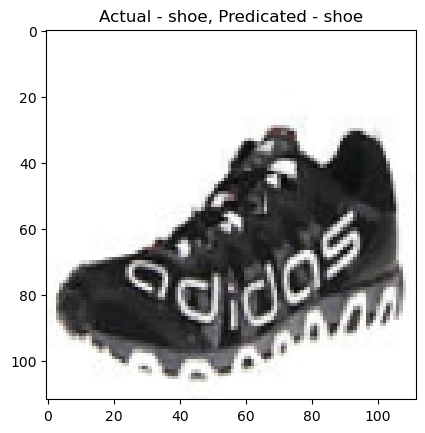

In [19]:
# Classify an image
test_transforms = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.ToTensor()
])

test_dataset = datasets.ImageFolder(
    root=val_dir,
    transform=test_transforms,
    target_transform=None
)

random_index = torch.randint(0, len(test_dataset), (1,)).item()
image, label = test_dataset[random_index]
image = image.to(device)

loaded_model.eval()
with torch.inference_mode():
    encoder_output = loaded_model.encode(image.unsqueeze(dim=0))
    y_logits = loaded_model.project(encoder_output)
    predicted_label = torch.argmax(y_logits, dim=1)
    
plt.title(f'Actual - {class_names[label]}, Predicated - {class_names[predicted_label.item()]}')
plt.imshow(image.cpu().permute(1, 2, 0))